In [ ]:
import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

## EXERCISE 1: Design, Train and Test a CNN

Create a CNN using Keras library with the followings specifications:

> __QUESTION 1(a):__  DATASET: Load the [CIFAR10](https://keras.io/api/datasets/cifar10/) dataset contains 60,000 color images in 10 classes, with 6,000 images in each class.
You can use the function datasets.cifar10.load_data() to load the dataset after importing the keras dataset with the command: from tensorflow.keras import datasets. Split the dataset in train and test set

In [ ]:
#@title SOL

from tensorflow.keras import datasets
import keras
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Preprocessing
x_train=x_train/256.0
x_test=x_test/256.0


> __QUESTION 1(b):__  Plot some samples in the dataset to visualize the kind of data

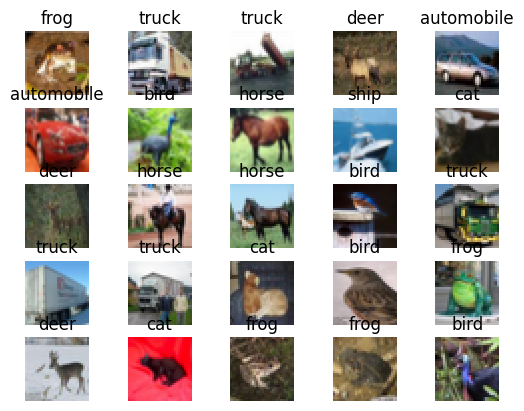

In [ ]:
#@title SOL

for i in range(25):
    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[(y_train[i][0])])
    plt.axis("off")



> __QUESTION 1(c):__  Build and compile a CNN model composed with:
* Conv2D with 32 filters, kernel size 3X3, activation function relu
* MaxPooling 2D with kernel size 2x2
* Conv2D with 64 filters kernel size 3X3, activation function relu
* MaxPooling 2D with kernel size 2x2
* Conv2D with 64 filters kernel size 3X3, activation function relu
* Flatten layer
* Dense layer with 64 neurons and activation function relu
* Final Dense layer for returning 10 classes
* adam as optmizer


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

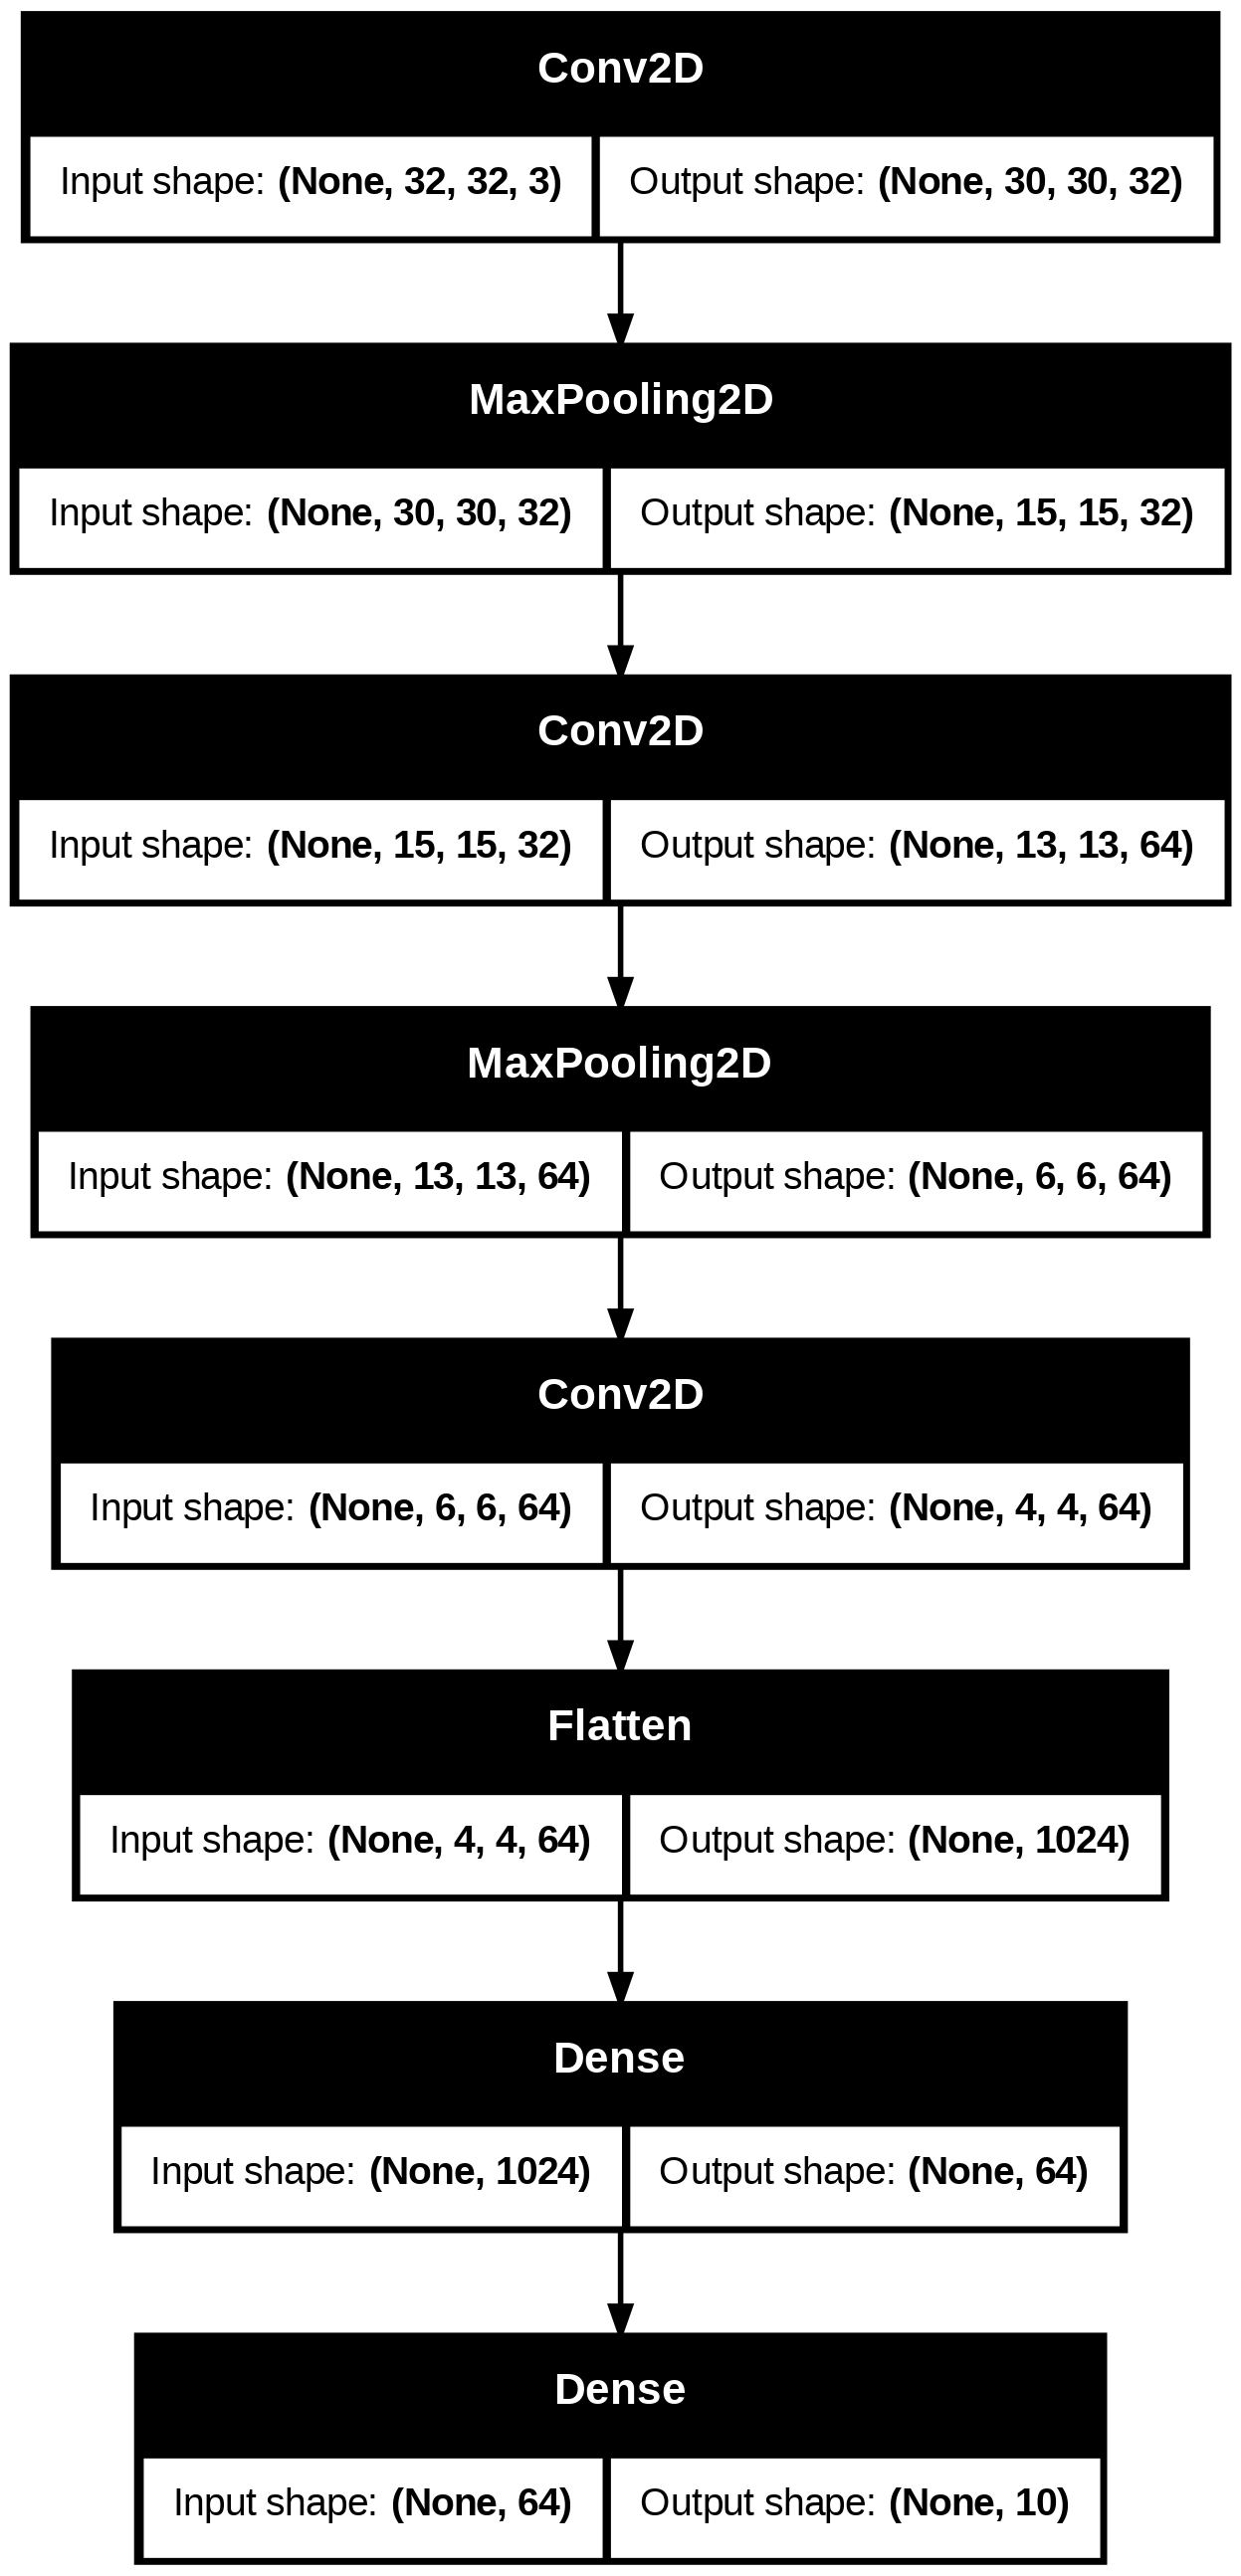

In [ ]:
#@title SOL

from keras import models, layers

model = models.Sequential()
model.add(layers.Input(shape=(32, 32, 3)))
model.add(layers.Conv2D(32, (3, 3), 1, activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

model.summary()

model.compile(optimizer='adam',
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

keras.utils.plot_model(model, show_shapes=True)



> __QUESTION 1(d):__ Train and test on the CIFAR10 dataset with 10 epochs to check the performance

In [ ]:
y_predicted = model.predict(x_test)
y_predicted[0]

# softmax
# Y_pred = np.argmax(y_predicted,axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([-3.4010651e+00, -4.2499409e+00,  7.2999984e-02,  3.8694651e+00,
       -3.7015646e+00,  2.1523724e+00, -3.5356656e-03, -2.2935176e+00,
       -7.6993239e-01, -4.3646059e+00], dtype=float32)

In [ ]:
#@title SOL
history = model.fit(x_train, y_train, epochs=10)

# Evaluate the model
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# Test model
y_predicted = model.predict(x_test)
y_predicted = np.argmax(y_predicted, axis=1)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.3334 - loss: 1.7979
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5533 - loss: 1.2398
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6270 - loss: 1.0515
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6665 - loss: 0.9524
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6964 - loss: 0.8697
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7123 - loss: 0.8158
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7336 - loss: 0.7538
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7475 - loss: 0.7191
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7578 - loss: 0.6875
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7736 - loss: 0.6474
Test loss: 0.8577931523323059
Test accuracy: 0.717199981212616
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step



> __QUESTION 1(e):__ Compute the confusion matrix


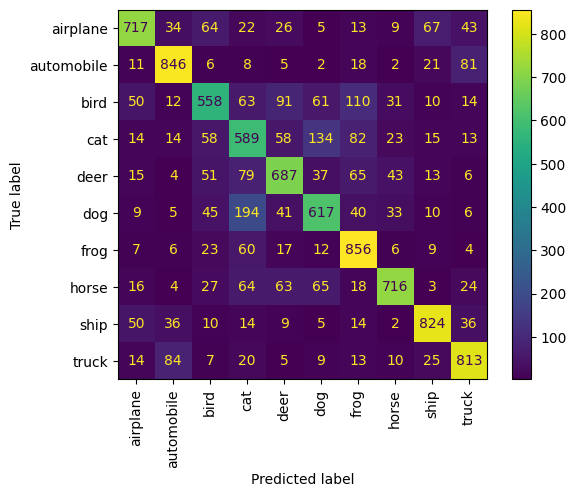

In [ ]:
#@title SOL

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

cm = confusion_matrix(y_test, y_predicted)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot()
plt.xticks(rotation=90)
plt.show()

> __QUESTION 1(f):__ : Test your model on new images about the available class that you can download from the web.

Downloading...
From: https://drive.google.com/uc?id=1WTXIeWjoXwDgw2NGygAe11TRHpz4Y0cT
To: /content/img.jpg
100%|██████████| 1.25M/1.25M [00:00<00:00, 10.1MB/s]


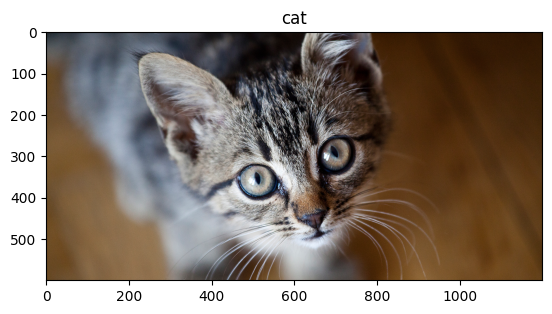

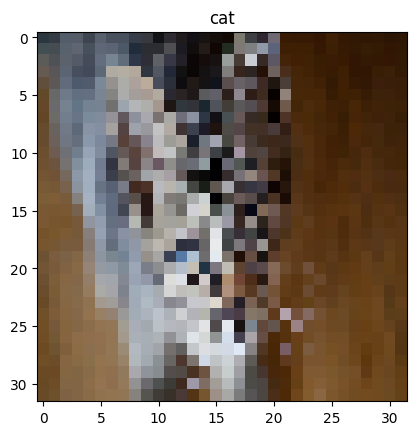

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step

 PREDICTED LABEL: dog


Downloading...
From: https://drive.google.com/uc?id=1GlYCU3N4WqqIrIcC9V_1EtjNOYijWUsW
To: /content/img.jpg
100%|██████████| 87.5k/87.5k [00:00<00:00, 1.35MB/s]


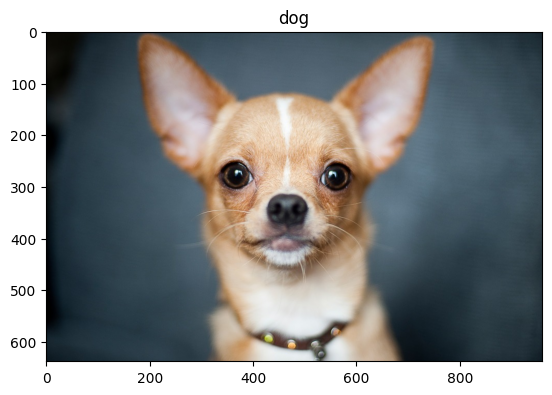

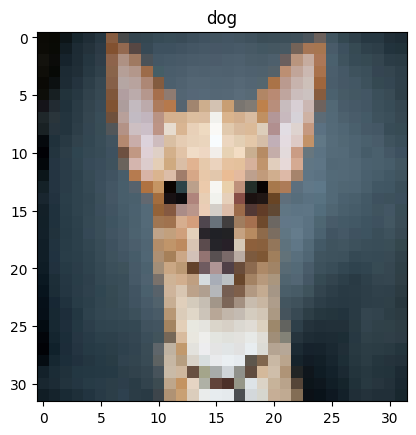

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

 PREDICTED LABEL: cat


Downloading...
From: https://drive.google.com/uc?id=14yYM5lYd6xug6_P3y3x96qeN0I7e5lsw
To: /content/img.jpg
100%|██████████| 25.9k/25.9k [00:00<00:00, 8.16MB/s]


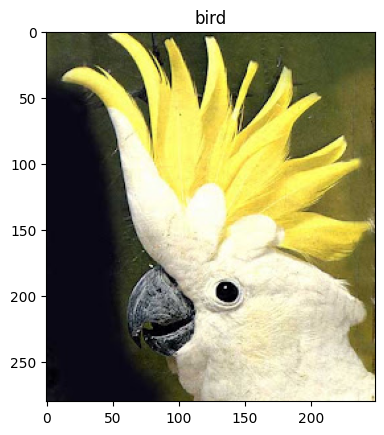

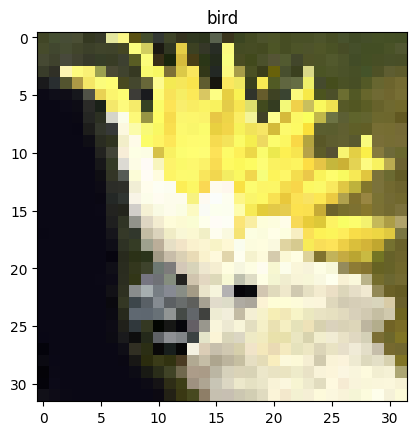

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step

 PREDICTED LABEL: cat


Downloading...
From: https://drive.google.com/uc?id=1eWSdGzzB089nXwaj9BLurPXKTHK2mULg
To: /content/img.jpg
100%|██████████| 125k/125k [00:00<00:00, 2.24MB/s]


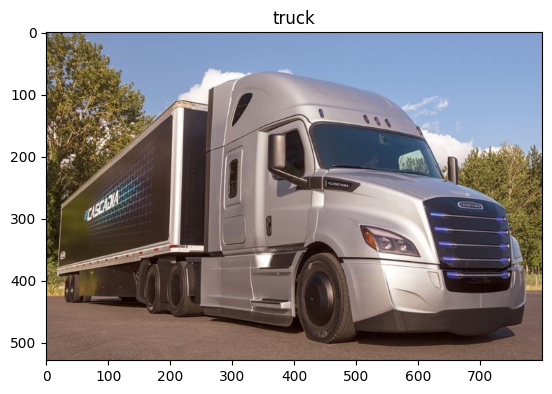

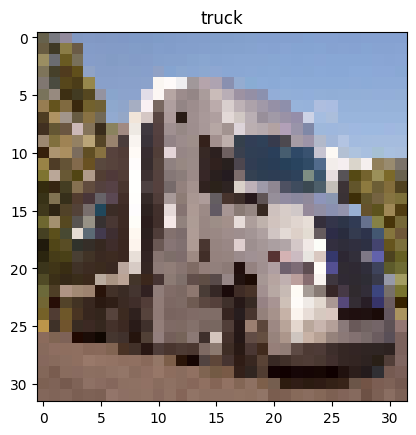

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

 PREDICTED LABEL: truck


Downloading...
From: https://drive.google.com/uc?id=1ato5-H1uJm1ET95hIdnh6O8F3kplxkEy
To: /content/img.jpg
100%|██████████| 14.1k/14.1k [00:00<00:00, 38.2MB/s]


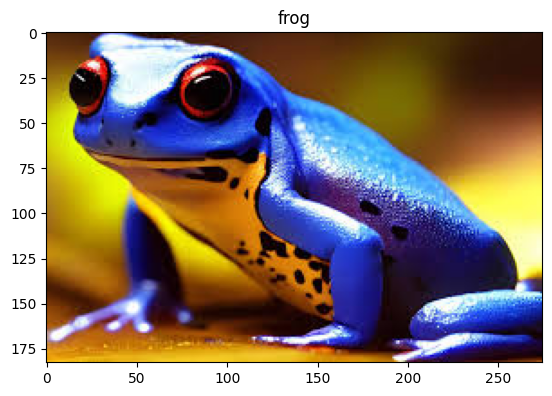

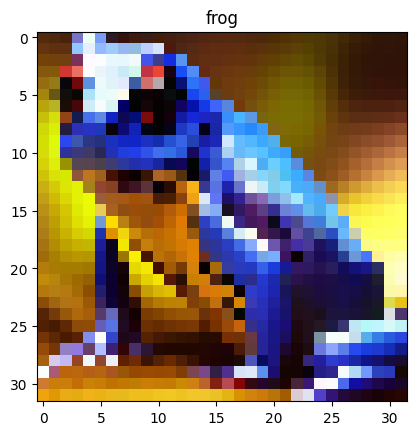

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

 PREDICTED LABEL: automobile


Downloading...
From: https://drive.google.com/uc?id=1B6ocPfCNxTX5aq8CCM196NuOFgxhX-if
To: /content/img.jpg
100%|██████████| 78.9k/78.9k [00:00<00:00, 2.91MB/s]


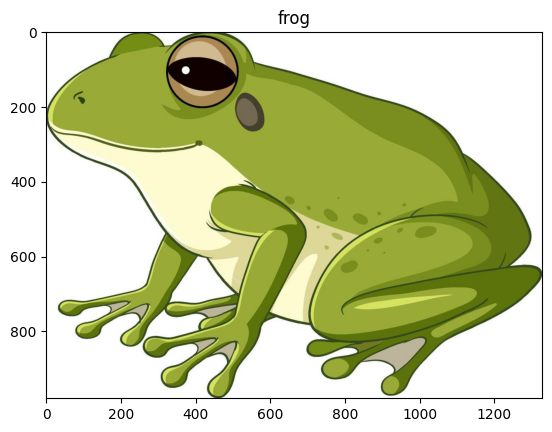

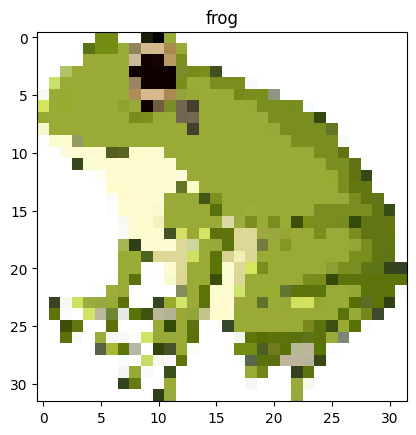

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

 PREDICTED LABEL: frog


Downloading...
From: https://drive.google.com/uc?id=1Q73FXbnG5EiKMNkjnfzbCUjBeVtzlz3i
To: /content/img.jpg
100%|██████████| 9.85k/9.85k [00:00<00:00, 9.20MB/s]


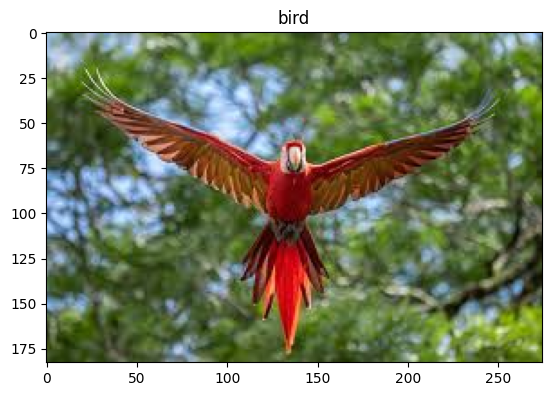

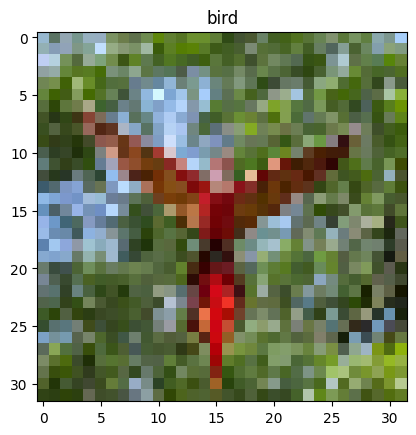

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

 PREDICTED LABEL: deer


Downloading...
From: https://drive.google.com/uc?id=11EKbn0jlXNvHmXMRHLrOA0xgQq7a_Gph
To: /content/img.jpg
100%|██████████| 165k/165k [00:00<00:00, 3.73MB/s]


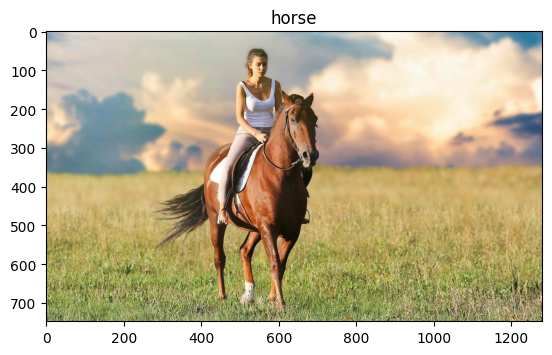

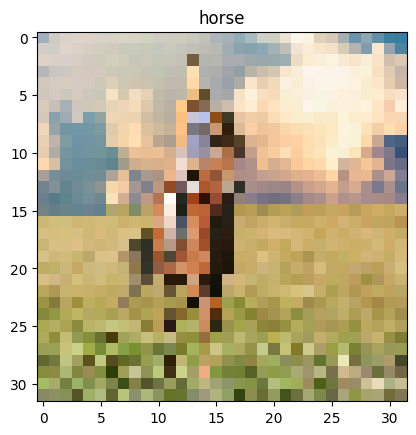

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

 PREDICTED LABEL: horse


Downloading...
From: https://drive.google.com/uc?id=1xVWmXw_BWIGpphw055JovE78ZQGrDYyZ
To: /content/img.jpg
100%|██████████| 57.5k/57.5k [00:00<00:00, 7.26MB/s]


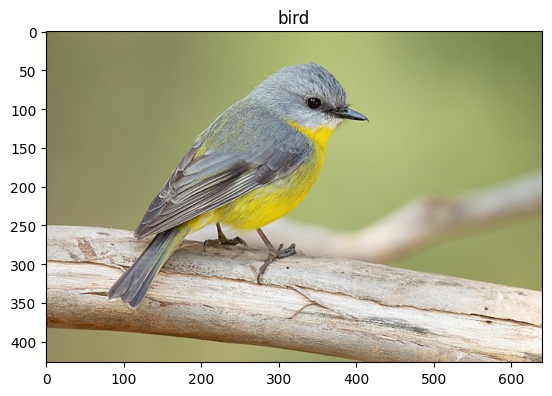

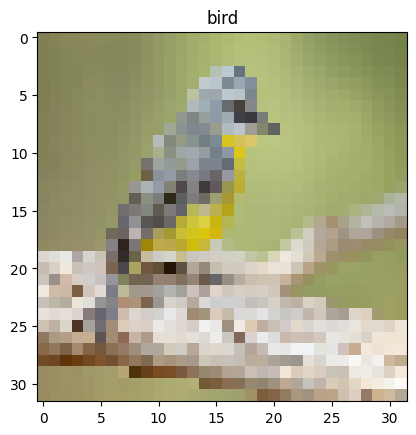

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step

 PREDICTED LABEL: bird


In [ ]:
#@title SOL

#QUESTION 1(f):Test your model on new images about the available class that you can download from the web
!pip install gdown
import gdown
import cv2

# new images : NB as explained during the lecture, you can retrieve the id from the shared link in drive
images_url = ["https://drive.google.com/uc?id=1WTXIeWjoXwDgw2NGygAe11TRHpz4Y0cT",
              "https://drive.google.com/uc?id=1GlYCU3N4WqqIrIcC9V_1EtjNOYijWUsW",
              "https://drive.google.com/uc?id=14yYM5lYd6xug6_P3y3x96qeN0I7e5lsw",
              "https://drive.google.com/uc?id=1eWSdGzzB089nXwaj9BLurPXKTHK2mULg",
              "https://drive.google.com/uc?id=1ato5-H1uJm1ET95hIdnh6O8F3kplxkEy",
              "https://drive.google.com/uc?id=1B6ocPfCNxTX5aq8CCM196NuOFgxhX-if",
              "https://drive.google.com/uc?id=1Q73FXbnG5EiKMNkjnfzbCUjBeVtzlz3i",
              "https://drive.google.com/uc?id=11EKbn0jlXNvHmXMRHLrOA0xgQq7a_Gph",
              "https://drive.google.com/uc?id=1xVWmXw_BWIGpphw055JovE78ZQGrDYyZ"]

images_label = [class_names.index('cat'),
                class_names.index('dog'),
                class_names.index('bird'),
                class_names.index('truck'),
                class_names.index('frog'),
                class_names.index('frog'),
                class_names.index('bird'),
                class_names.index('horse'),
                class_names.index('bird')]

for u in range(len(images_url)):

  url = images_url[u]
  output = "/content/img.jpg"  # Output path for the downloaded image from Google drive

  # Download and read the image
  gdown.download(url, output, quiet=False)
  img = cv2.imread(output, cv2.IMREAD_COLOR)
  rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # to adjust the color

  # Show the image
  plt.imshow(rgb_img)
  plt.title(class_names[images_label[u]])
  plt.show()

  # Resize the image according to the dimension accepted by the model
  resize = tf.image.resize(rgb_img, (32,32)) # See before the CNN works with 32x32 as image size
  plt.imshow(resize.numpy().astype(int))
  plt.title(class_names[images_label[u]])
  plt.show()

  # Predictions
  pred = model.predict(np.expand_dims(resize/255, 0))
  print("\n PREDICTED LABEL: " + class_names[np.argmax(pred)])